# Two-Timescale Linear Dynamical System Model for AVB

## Modelling AVB's calcium response from ASH, AVA, and AVD

Based on the master-neuron model from **Meng et al. (2024)** *Science Advances*,
we extend the two-timescale framework (Equations 1–2) to multiple input neurons.

### Key idea
- **Fast (instantaneous) coupling** $a_i$ — maps to **electrical synapses (gap junctions)**
- **Slow (leaky-integrator) coupling** $b_i$, $\tau_i$ — maps to **chemical synapses**

### Connectivity constraints (→ AVB)

| Neuron | Gap junction (fast $a_i$) | Chemical synapse (slow $b_i$) |
|--------|:------------------------:|:----------------------------:|
| ASH    | ✗ → $a_{\text{ASH}}=0$  | ✓ → $b_{\text{ASH}}$ free   |
| AVA    | ✓ → $a_{\text{AVA}}$ free | ✓ → $b_{\text{AVA}}$ free   |
| AVD    | ✓ → $a_{\text{AVD}}$ free | ✗ → $b_{\text{AVD}}=0$       |

### Models compared
1. **Unconstrained** — all $a_i$, $b_i$, $\tau_i$ free (9 params)
2. **Constrained (feedforward)** — connectivity-enforced zeros (6 params)
3. **Constrained + feedback** — AVB→AVA chemical synapse adds a feedback loop
4. **Minimal electrical** — only AVA↔AVB gap junction; no AVD↔AVB or ASH↔AVD electrical (5 params)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, differential_evolution
from scipy.integrate import solve_ivp
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

sns.set_context('notebook', font_scale=1.1)
sns.set_style('ticks')
%matplotlib inline

colors = {'ASH': '#E74C3C', 'AVA': '#3498DB', 'AVB': '#2ECC71', 'AVD': '#9B59B6'}

## 1. Load Data & Compute Mean Traces

In [2]:
ASH = np.load('./ASH_Dauer_signal_260212.npy')  # (15, 200)
AVA = np.load('./AVA_Dauer_signal_260212.npy')  # (35, 200)
AVB = np.load('./AVB_Dauer_signal_260212.npy')  # (35, 200)
AVD = np.load('./AVD_Dauer_signal_260305.npy')  # (61, 200)

# Mean traces — used as population-level input signals
ash_mean = ASH.mean(axis=0)
ava_mean = AVA.mean(axis=0)
avb_mean = AVB.mean(axis=0)
avd_mean = AVD.mean(axis=0)

T = len(avb_mean)
t = np.arange(T)
dt = 1.0  # frame-based time step

inputs = {'ASH': ash_mean, 'AVA': ava_mean, 'AVD': avd_mean}

print(f'Timepoints: {T}')
for name, arr in [('ASH', ASH), ('AVA', AVA), ('AVB', AVB), ('AVD', AVD)]:
    print(f'  {name}: n={arr.shape[0]} animals')

Timepoints: 200
  ASH: n=15 animals
  AVA: n=35 animals
  AVB: n=35 animals
  AVD: n=61 animals


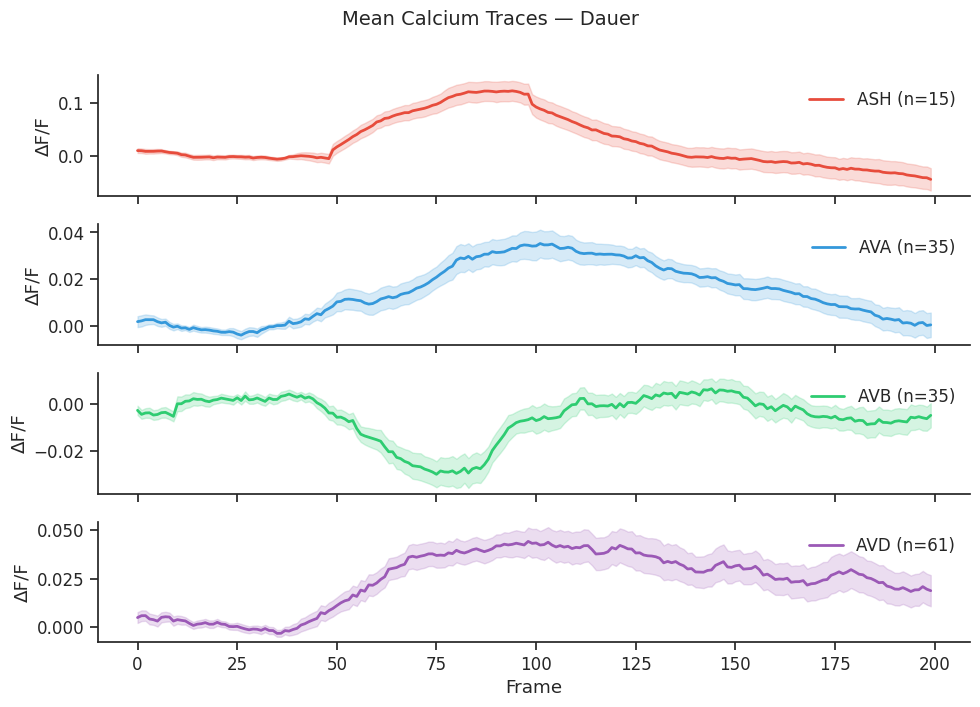

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, (name, arr) in zip(axes, [('ASH', ASH), ('AVA', AVA), ('AVB', AVB), ('AVD', AVD)]):
    mean = arr.mean(axis=0)
    sem = arr.std(axis=0) / np.sqrt(arr.shape[0])
    ax.fill_between(t, mean - sem, mean + sem, alpha=0.2, color=colors[name])
    ax.plot(t, mean, color=colors[name], lw=2, label=f'{name} (n={arr.shape[0]})')
    ax.set_ylabel('ΔF/F')
    ax.legend(loc='upper right', frameon=False)
    sns.despine(ax=ax)
axes[-1].set_xlabel('Frame')
fig.suptitle('Mean Calcium Traces — Dauer', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Two-Timescale Model: Core Functions

### General model (Meng et al. extended to multiple inputs)

$$x_{\text{AVB}}(t) = \sum_i a_i \cdot x_i(t) + \sum_i b_i \cdot y_i(t)$$

$$\frac{dy_i}{dt} = -\frac{1}{\tau_i} \cdot y_i + x_i$$

where $i \in \{\text{ASH, AVA, AVD}\}$.

- $a_i$: fast (electrical/gap-junction) coupling strength
- $b_i$: slow (chemical synapse) coupling strength  
- $\tau_i$: integration time constant for the slow component
- $y_i$: leaky-integrated (slow) copy of neuron $i$'s activity

In [4]:
def simulate_slow_integrator(x_input, tau, dt=1.0):
    """Simulate the leaky integrator: dy/dt = -y/tau + x_input.
    
    Uses exact exponential integration for numerical stability.
    """
    T = len(x_input)
    y = np.zeros(T)
    if tau <= 0:
        return y
    decay = np.exp(-dt / tau)
    for i in range(1, T):
        y[i] = decay * y[i-1] + dt * x_input[i-1]
    return y


def predict_avb_feedforward(params, x_ash, x_ava, x_avd, dt=1.0, constrained=True):
    """Predict AVB using feedforward two-timescale model.
    
    Constrained (6 params): a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA
    Unconstrained (9 params): a_ASH, a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA, b_AVD, tau_AVD
    """
    if constrained:
        a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA = params
        a_ASH = 0.0
        b_AVD = 0.0
        tau_AVD = 1.0  # dummy, not used
    else:
        a_ASH, a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA, b_AVD, tau_AVD = params
    
    # Fast (instantaneous) components
    fast = a_ASH * x_ash + a_AVA * x_ava + a_AVD * x_avd
    
    # Slow (leaky-integrator) components
    y_ash = simulate_slow_integrator(x_ash, tau_ASH, dt)
    y_ava = simulate_slow_integrator(x_ava, tau_AVA, dt)
    y_avd = simulate_slow_integrator(x_avd, tau_AVD, dt)
    
    slow = b_ASH * y_ash + b_AVA * y_ava + b_AVD * y_avd
    
    return fast + slow


def loss_feedforward(params, x_ash, x_ava, x_avd, target, dt=1.0, constrained=True):
    """Mean squared error loss."""
    pred = predict_avb_feedforward(params, x_ash, x_ava, x_avd, dt, constrained)
    return np.mean((pred - target) ** 2)


print('Core functions defined.')

Core functions defined.


## 3. Model A — Constrained Feedforward (6 parameters)

$$x_{\text{AVB}} = a_{\text{AVA}} \cdot x_{\text{AVA}} + a_{\text{AVD}} \cdot x_{\text{AVD}}
+ b_{\text{ASH}} \cdot y_{\text{ASH}} + b_{\text{AVA}} \cdot y_{\text{AVA}}$$

Connectivity constraints enforced:
- $a_{\text{ASH}} = 0$ (no gap junction ASH↔AVB)
- $b_{\text{AVD}} = 0$ (no chemical synapse AVD→AVB)

In [5]:
# --- Fit constrained feedforward model ---
# Parameters: [a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA]

bounds_constrained = [
    (-2, 2),      # a_AVA
    (-2, 2),      # a_AVD
    (-2, 2),      # b_ASH
    (1, 100),     # tau_ASH (frames)
    (-2, 2),      # b_AVA
    (1, 100),     # tau_AVA (frames)
]

result_constrained = differential_evolution(
    loss_feedforward, bounds_constrained,
    args=(ash_mean, ava_mean, avd_mean, avb_mean, dt, True),
    seed=42, maxiter=2000, tol=1e-12, polish=True
)

pred_constrained = predict_avb_feedforward(
    result_constrained.x, ash_mean, ava_mean, avd_mean, dt, constrained=True
)
r2_constrained = r2_score(avb_mean, pred_constrained)

param_names_c = ['a_AVA', 'a_AVD', 'b_ASH', 'τ_ASH', 'b_AVA', 'τ_AVA']
print('=== Model A: Constrained Feedforward (6 params) ===')
print(f'R² = {r2_constrained:.4f}')
print(f'MSE = {result_constrained.fun:.8f}')
print('\nFitted parameters:')
for name, val in zip(param_names_c, result_constrained.x):
    print(f'  {name:>6s} = {val:+.4f}')

=== Model A: Constrained Feedforward (6 params) ===
R² = 0.8688
MSE = 0.00001205

Fitted parameters:
   a_AVA = -0.4828
   a_AVD = -0.9384
   b_ASH = +0.0014
   τ_ASH = +61.2407
   b_AVA = +0.1024
   τ_AVA = +14.2235


## 4. Model B — Unconstrained Feedforward (9 parameters)

All $a_i$, $b_i$, $\tau_i$ free — no connectivity priors.

In [6]:
# Parameters: [a_ASH, a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA, b_AVD, tau_AVD]

bounds_unconstrained = [
    (-2, 2),      # a_ASH
    (-2, 2),      # a_AVA
    (-2, 2),      # a_AVD
    (-2, 2),      # b_ASH
    (1, 100),     # tau_ASH
    (-2, 2),      # b_AVA
    (1, 100),     # tau_AVA
    (-2, 2),      # b_AVD
    (1, 100),     # tau_AVD
]

result_unconstrained = differential_evolution(
    loss_feedforward, bounds_unconstrained,
    args=(ash_mean, ava_mean, avd_mean, avb_mean, dt, False),
    seed=42, maxiter=2000, tol=1e-12, polish=True
)

pred_unconstrained = predict_avb_feedforward(
    result_unconstrained.x, ash_mean, ava_mean, avd_mean, dt, constrained=False
)
r2_unconstrained = r2_score(avb_mean, pred_unconstrained)

param_names_u = ['a_ASH', 'a_AVA', 'a_AVD', 'b_ASH', 'τ_ASH', 'b_AVA', 'τ_AVA', 'b_AVD', 'τ_AVD']
print('=== Model B: Unconstrained Feedforward (9 params) ===')
print(f'R² = {r2_unconstrained:.4f}')
print(f'MSE = {result_unconstrained.fun:.8f}')
print('\nFitted parameters:')
for name, val in zip(param_names_u, result_unconstrained.x):
    print(f'  {name:>6s} = {val:+.4f}')

=== Model B: Unconstrained Feedforward (9 params) ===
R² = 0.9326
MSE = 0.00000619

Fitted parameters:
   a_ASH = -0.1437
   a_AVA = -0.3125
   a_AVD = +0.1271
   b_ASH = +0.0115
   τ_ASH = +53.8778
   b_AVA = +0.0660
   τ_AVA = +5.0624
   b_AVD = -0.1757
   τ_AVD = +4.6905


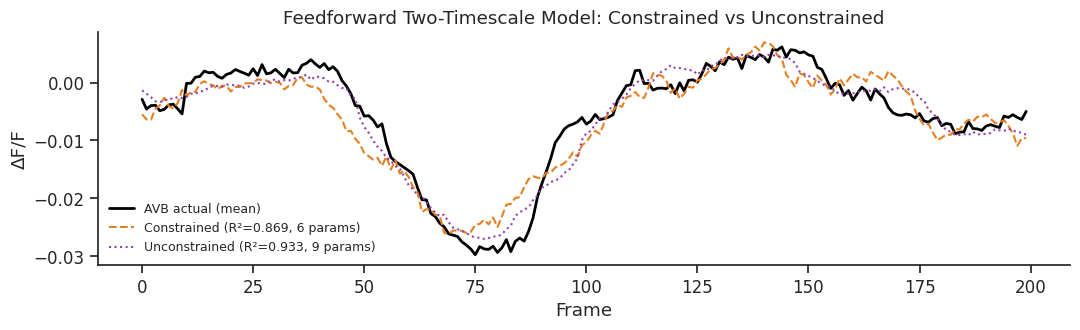

In [7]:
# --- Compare predictions: constrained vs unconstrained ---
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, avb_mean, 'k-', lw=2, label='AVB actual (mean)')
ax.plot(t, pred_constrained, '--', color='#E67E22', lw=1.5,
        label=f'Constrained (R²={r2_constrained:.3f}, 6 params)')
ax.plot(t, pred_unconstrained, ':', color='#8E44AD', lw=1.5,
        label=f'Unconstrained (R²={r2_unconstrained:.3f}, 9 params)')
ax.set_xlabel('Frame')
ax.set_ylabel('ΔF/F')
ax.set_title('Feedforward Two-Timescale Model: Constrained vs Unconstrained')
ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Decompose Fast vs Slow Contributions

Visualise what each neuron contributes through the fast (electrical) vs slow (chemical) pathway.

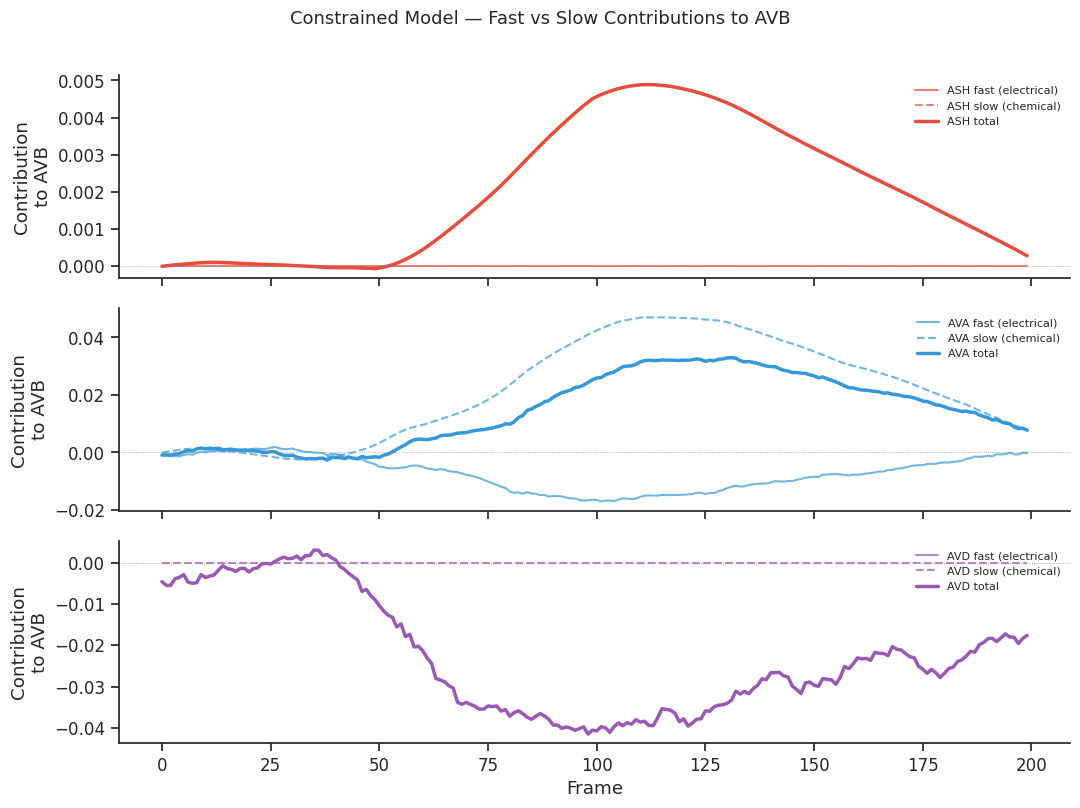

In [8]:
def decompose_contributions(params, x_ash, x_ava, x_avd, dt=1.0, constrained=True):
    """Return individual fast and slow contributions per neuron."""
    if constrained:
        a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA = params
        a_ASH, b_AVD, tau_AVD = 0.0, 0.0, 1.0
    else:
        a_ASH, a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA, b_AVD, tau_AVD = params
    
    contributions = {}
    for name, x, a, b, tau in [
        ('ASH', x_ash, a_ASH, b_ASH, tau_ASH),
        ('AVA', x_ava, a_AVA, b_AVA, tau_AVA),
        ('AVD', x_avd, a_AVD, b_AVD, tau_AVD),
    ]:
        fast = a * x
        slow = b * simulate_slow_integrator(x, tau, dt)
        contributions[name] = {'fast': fast, 'slow': slow, 'total': fast + slow}
    return contributions


contrib_c = decompose_contributions(result_constrained.x, ash_mean, ava_mean, avd_mean, constrained=True)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, name in zip(axes, ['ASH', 'AVA', 'AVD']):
    c = contrib_c[name]
    ax.plot(t, c['fast'], '-', color=colors[name], lw=1.5, alpha=0.7, label=f'{name} fast (electrical)')
    ax.plot(t, c['slow'], '--', color=colors[name], lw=1.5, alpha=0.7, label=f'{name} slow (chemical)')
    ax.plot(t, c['total'], '-', color=colors[name], lw=2.5, label=f'{name} total')
    ax.axhline(0, color='grey', ls=':', lw=0.5)
    ax.set_ylabel('Contribution\nto AVB')
    ax.legend(loc='upper right', frameon=False, fontsize=8)
    sns.despine(ax=ax)

axes[-1].set_xlabel('Frame')
fig.suptitle('Constrained Model — Fast vs Slow Contributions to AVB', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Model C — Constrained with Feedback (AVB→AVA)

AVB sends a chemical synapse to AVA. This creates a feedback loop:

$$x_{\text{AVA}}^{\text{eff}}(t) = x_{\text{AVA}}^{\text{obs}}(t) + c_{\text{fb}} \cdot z(t)$$

$$\frac{dz}{dt} = -\frac{1}{\tau_{\text{fb}}} \cdot z + x_{\text{AVB}}(t)$$

where $z$ is the slow-integrated feedback from AVB, and $x_{\text{AVA}}^{\text{eff}}$
replaces $x_{\text{AVA}}$ in the feedforward equations.

This adds **2 parameters**: $c_{\text{fb}}$ and $\tau_{\text{fb}}$ (total: **8 params**).

Since AVB appears on both sides, we solve the coupled system iteratively.

In [9]:
def predict_avb_feedback(params, x_ash, x_ava_obs, x_avd, dt=1.0, n_iter=5):
    """Predict AVB with AVB→AVA chemical feedback.
    
    Parameters (8): a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA, c_fb, tau_fb
    
    Solved iteratively: start with feedforward prediction of AVB,
    then use it to compute feedback onto AVA, re-predict AVB, repeat.
    """
    a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA, c_fb, tau_fb = params
    T = len(x_ash)
    
    # Initial AVB estimate: feedforward (no feedback)
    ff_params = [a_AVA, a_AVD, b_ASH, tau_ASH, b_AVA, tau_AVA]
    x_avb_est = predict_avb_feedforward(ff_params, x_ash, x_ava_obs, x_avd, dt, constrained=True)
    
    for _ in range(n_iter):
        # Feedback: AVB → (slow chemical) → modifies AVA
        z = simulate_slow_integrator(x_avb_est, tau_fb, dt)
        x_ava_eff = x_ava_obs + c_fb * z
        
        # Re-predict AVB with modified AVA
        y_ash = simulate_slow_integrator(x_ash, tau_ASH, dt)
        y_ava = simulate_slow_integrator(x_ava_eff, tau_AVA, dt)
        
        x_avb_est = a_AVA * x_ava_eff + a_AVD * x_avd + b_ASH * y_ash + b_AVA * y_ava
    
    return x_avb_est


def loss_feedback(params, x_ash, x_ava, x_avd, target, dt=1.0):
    pred = predict_avb_feedback(params, x_ash, x_ava, x_avd, dt)
    return np.mean((pred - target) ** 2)


bounds_feedback = [
    (-2, 2),      # a_AVA
    (-2, 2),      # a_AVD
    (-2, 2),      # b_ASH
    (1, 100),     # tau_ASH
    (-2, 2),      # b_AVA
    (1, 100),     # tau_AVA
    (-2, 2),      # c_fb (feedback strength)
    (1, 100),     # tau_fb (feedback time constant)
]

result_feedback = differential_evolution(
    loss_feedback, bounds_feedback,
    args=(ash_mean, ava_mean, avd_mean, avb_mean, dt),
    seed=42, maxiter=2000, tol=1e-12, polish=True
)

pred_feedback = predict_avb_feedback(
    result_feedback.x, ash_mean, ava_mean, avd_mean, dt
)
r2_feedback = r2_score(avb_mean, pred_feedback)

param_names_fb = ['a_AVA', 'a_AVD', 'b_ASH', 'τ_ASH', 'b_AVA', 'τ_AVA', 'c_fb', 'τ_fb']
print('=== Model C: Constrained + Feedback (8 params) ===')
print(f'R² = {r2_feedback:.4f}')
print(f'MSE = {result_feedback.fun:.8f}')
print('\nFitted parameters:')
for name, val in zip(param_names_fb, result_feedback.x):
    print(f'  {name:>6s} = {val:+.4f}')

=== Model C: Constrained + Feedback (8 params) ===
R² = 0.9595
MSE = 0.00000372

Fitted parameters:
   a_AVA = -0.1645
   a_AVD = -0.2307
   b_ASH = +0.0049
   τ_ASH = +1.0000
   b_AVA = +0.0357
   τ_AVA = +4.1211
    c_fb = -1.5826
    τ_fb = +36.2851


## 6b. Model D — Minimal Electrical Connectivity (5 parameters)

What if AVD↔AVB and ASH↔AVD **do not** have functional electrical synapses?
This reduces to only **AVA↔AVB** having a gap junction.

| Neuron | Gap junction (fast $a_i$) | Chemical synapse (slow $b_i$) |
|--------|:------------------------:|:----------------------------:|
| ASH    | ✗ → $a_{\text{ASH}}=0$  | ✓ → $b_{\text{ASH}}$ free   |
| AVA    | ✓ → $a_{\text{AVA}}$ free | ✓ → $b_{\text{AVA}}$ free   |
| AVD    | ✗ → $a_{\text{AVD}}=0$  | ✗ → $b_{\text{AVD}}=0$       |

$$x_{\text{AVB}} = a_{\text{AVA}} \cdot x_{\text{AVA}} + b_{\text{ASH}} \cdot y_{\text{ASH}} + b_{\text{AVA}} \cdot y_{\text{AVA}}$$

5 free parameters: $a_{\text{AVA}}, b_{\text{ASH}}, \tau_{\text{ASH}}, b_{\text{AVA}}, \tau_{\text{AVA}}$.

This is the most parsimonious model — and closest to the original Meng et al.
single-input model, now extended with ASH chemical input.

Comparing D vs A directly tests **whether the AVD gap junction contributes**.

In [10]:
def predict_avb_minimal(params, x_ash, x_ava, x_avd, dt=1.0):
    """Predict AVB with minimal electrical connectivity.
    
    Only AVA↔AVB gap junction; no AVD↔AVB, no ASH↔AVB electrical.
    Parameters (5): a_AVA, b_ASH, tau_ASH, b_AVA, tau_AVA
    """
    a_AVA, b_ASH, tau_ASH, b_AVA, tau_AVA = params
    
    # Fast: only AVA
    fast = a_AVA * x_ava
    
    # Slow: ASH chemical + AVA chemical/extrasynaptic
    y_ash = simulate_slow_integrator(x_ash, tau_ASH, dt)
    y_ava = simulate_slow_integrator(x_ava, tau_AVA, dt)
    slow = b_ASH * y_ash + b_AVA * y_ava
    
    return fast + slow


def loss_minimal(params, x_ash, x_ava, x_avd, target, dt=1.0):
    pred = predict_avb_minimal(params, x_ash, x_ava, x_avd, dt)
    return np.mean((pred - target) ** 2)


bounds_minimal = [
    (-2, 2),      # a_AVA
    (-2, 2),      # b_ASH
    (1, 100),     # tau_ASH
    (-2, 2),      # b_AVA
    (1, 100),     # tau_AVA
]

result_minimal = differential_evolution(
    loss_minimal, bounds_minimal,
    args=(ash_mean, ava_mean, avd_mean, avb_mean, dt),
    seed=42, maxiter=2000, tol=1e-12, polish=True
)

pred_minimal = predict_avb_minimal(
    result_minimal.x, ash_mean, ava_mean, avd_mean, dt
)
r2_minimal = r2_score(avb_mean, pred_minimal)

param_names_m = ['a_AVA', 'b_ASH', 'τ_ASH', 'b_AVA', 'τ_AVA']
print('=== Model D: Minimal Electrical (5 params) ===')
print(f'R² = {r2_minimal:.4f}')
print(f'MSE = {result_minimal.fun:.8f}')
print('\nFitted parameters:')
for name, val in zip(param_names_m, result_minimal.x):
    print(f'  {name:>6s} = {val:+.4f}')

# Direct comparison: does the AVD gap junction matter?
print(f'\n--- AVD gap junction contribution ---')
print(f'  Model A (with AVD gap jn):    R² = {r2_constrained:.4f}  (6 params)')
print(f'  Model D (without AVD gap jn): R² = {r2_minimal:.4f}  (5 params)')
print(f'  ΔR² = {r2_constrained - r2_minimal:+.4f}')

=== Model D: Minimal Electrical (5 params) ===
R² = 0.6160
MSE = 0.00003527

Fitted parameters:
   a_AVA = -1.6196
   b_ASH = +0.0230
   τ_ASH = +52.3221
   b_AVA = -0.1119
   τ_AVA = +6.5382

--- AVD gap junction contribution ---
  Model A (with AVD gap jn):    R² = 0.8688  (6 params)
  Model D (without AVD gap jn): R² = 0.6160  (5 params)
  ΔR² = +0.2529


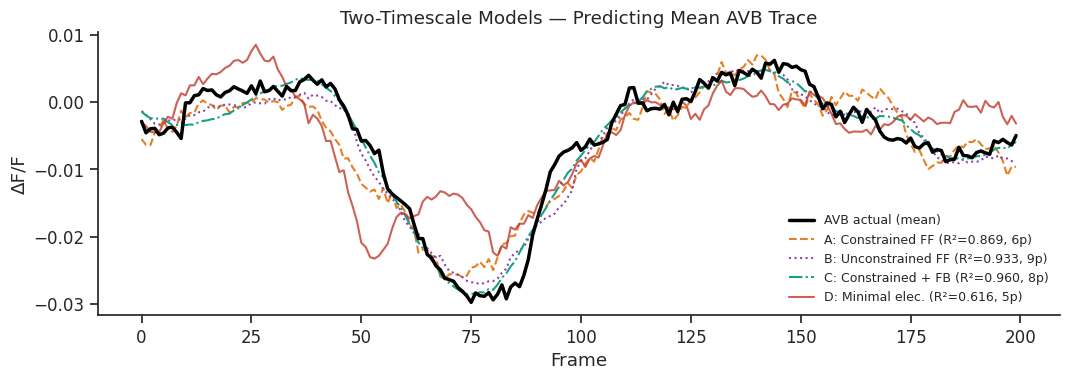

In [11]:
# --- All four models compared ---
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, avb_mean, 'k-', lw=2.5, label='AVB actual (mean)', zorder=5)
ax.plot(t, pred_constrained, '--', color='#E67E22', lw=1.5,
        label=f'A: Constrained FF (R²={r2_constrained:.3f}, 6p)')
ax.plot(t, pred_unconstrained, ':', color='#8E44AD', lw=1.5,
        label=f'B: Unconstrained FF (R²={r2_unconstrained:.3f}, 9p)')
ax.plot(t, pred_feedback, '-.', color='#16A085', lw=1.5,
        label=f'C: Constrained + FB (R²={r2_feedback:.3f}, 8p)')
ax.plot(t, pred_minimal, '-', color='#C0392B', lw=1.5, alpha=0.8,
        label=f'D: Minimal elec. (R²={r2_minimal:.3f}, 5p)')
ax.set_xlabel('Frame')
ax.set_ylabel('ΔF/F')
ax.set_title('Two-Timescale Models — Predicting Mean AVB Trace')
ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## 7. Cross-Validation Across Individual AVB Animals

Fit on the mean trace, evaluate on each of the 35 individual AVB traces.

In [12]:
# Evaluate all 4 models on individual AVB traces
r2_individuals = {'Constrained FF': [], 'Unconstrained FF': [], 'Constrained + FB': [], 'Minimal elec.': []}

for i in range(AVB.shape[0]):
    y_i = AVB[i]
    r2_individuals['Constrained FF'].append(r2_score(y_i, pred_constrained))
    r2_individuals['Unconstrained FF'].append(r2_score(y_i, pred_unconstrained))
    r2_individuals['Constrained + FB'].append(r2_score(y_i, pred_feedback))
    r2_individuals['Minimal elec.'].append(r2_score(y_i, pred_minimal))

print('R² on individual AVB traces (model fit on mean trace):\n')
for model_name, r2s in r2_individuals.items():
    r2s = np.array(r2s)
    frac_pos = np.mean(r2s > 0)
    print(f'  {model_name:20s}: mean={r2s.mean():.4f}, median={np.median(r2s):.4f}, '
          f'frac(R²>0)={frac_pos:.2f}')

R² on individual AVB traces (model fit on mean trace):

  Constrained FF      : mean=-0.1913, median=0.0395, frac(R²>0)=0.51
  Unconstrained FF    : mean=-0.1835, median=0.0825, frac(R²>0)=0.51
  Constrained + FB    : mean=-0.1838, median=0.0558, frac(R²>0)=0.51
  Minimal elec.       : mean=-0.2242, median=-0.0495, frac(R²>0)=0.49


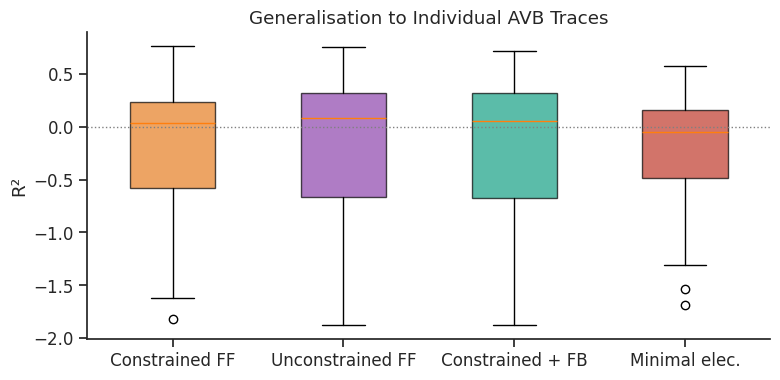

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
model_names = list(r2_individuals.keys())
model_colors = ['#E67E22', '#8E44AD', '#16A085', '#C0392B']
bp = ax.boxplot([r2_individuals[m] for m in model_names],
                labels=model_names, patch_artist=True,
                boxprops=dict(alpha=0.7), widths=0.5)
for patch, c in zip(bp['boxes'], model_colors):
    patch.set_facecolor(c)
ax.axhline(0, color='grey', ls=':', lw=1)
ax.set_ylabel('R²')
ax.set_title('Generalisation to Individual AVB Traces')
sns.despine()
plt.tight_layout()
plt.show()

## 8. Per-Animal Refitting (Constrained Model)

Refit the constrained model to each individual AVB trace to assess
parameter variability across animals.

In [14]:
fitted_params_per_animal = []
r2_refit = []

for i in range(AVB.shape[0]):
    y_i = AVB[i]
    res = differential_evolution(
        loss_feedforward, bounds_constrained,
        args=(ash_mean, ava_mean, avd_mean, y_i, dt, True),
        seed=42, maxiter=1000, tol=1e-10, polish=True
    )
    fitted_params_per_animal.append(res.x)
    pred_i = predict_avb_feedforward(res.x, ash_mean, ava_mean, avd_mean, dt, constrained=True)
    r2_refit.append(r2_score(y_i, pred_i))

fitted_params_per_animal = np.array(fitted_params_per_animal)
r2_refit = np.array(r2_refit)

print(f'Per-animal refit R²: mean={r2_refit.mean():.4f}, '
      f'median={np.median(r2_refit):.4f}, range=[{r2_refit.min():.4f}, {r2_refit.max():.4f}]')

Per-animal refit R²: mean=0.6590, median=0.6649, range=[0.2431, 0.9518]


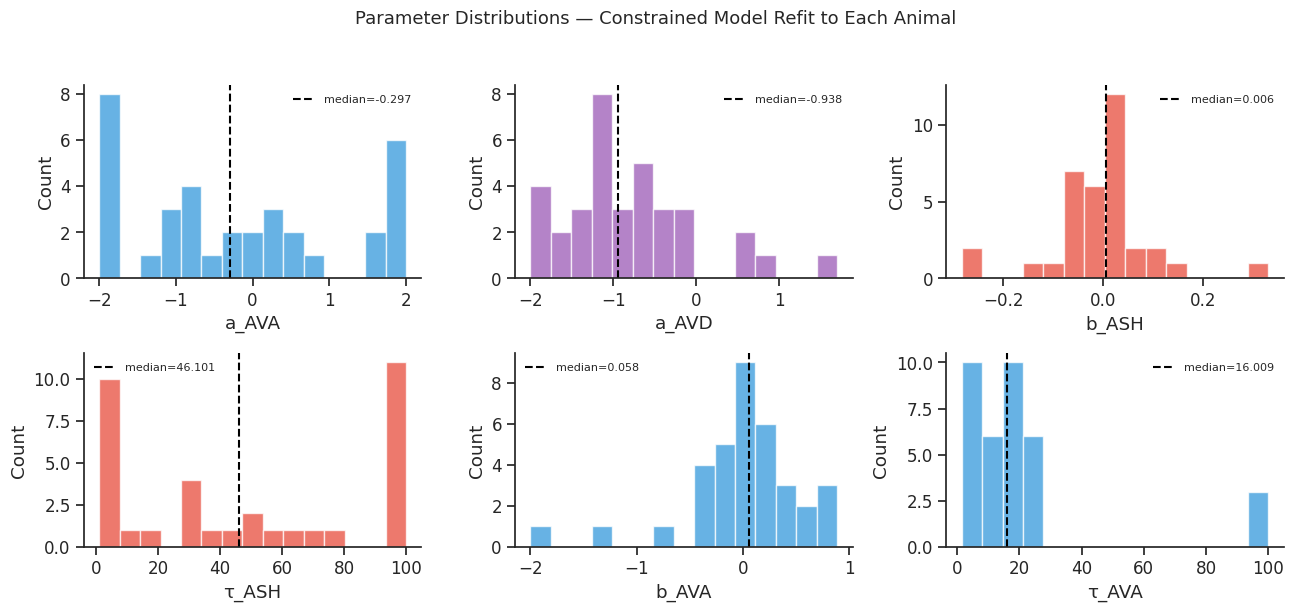

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.ravel()

param_colors = [colors['AVA'], colors['AVD'], colors['ASH'], colors['ASH'], colors['AVA'], colors['AVA']]

for j, (name, ax) in enumerate(zip(param_names_c, axes)):
    vals = fitted_params_per_animal[:, j]
    ax.hist(vals, bins=15, color=param_colors[j], edgecolor='white', alpha=0.75)
    ax.axvline(np.median(vals), color='k', ls='--', lw=1.5, label=f'median={np.median(vals):.3f}')
    ax.set_xlabel(name)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

fig.suptitle('Parameter Distributions — Constrained Model Refit to Each Animal', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Model Comparison — AIC / BIC

Compare models accounting for complexity using information criteria.

In [16]:
def compute_aic_bic(mse, n, k):
    """Compute AIC and BIC from MSE.
    n: number of data points, k: number of parameters.
    """
    ll = -n / 2 * (np.log(2 * np.pi * mse) + 1)  # log-likelihood (Gaussian)
    aic = 2 * k - 2 * ll
    bic = k * np.log(n) - 2 * ll
    return aic, bic


models_summary = [
    ('A: Constrained FF',    6, result_constrained.fun,    r2_constrained),
    ('B: Unconstrained FF',  9, result_unconstrained.fun,  r2_unconstrained),
    ('C: Constrained + FB',  8, result_feedback.fun,       r2_feedback),
    ('D: Minimal elec.',     5, result_minimal.fun,        r2_minimal),
]

print(f'{"Model":25s} {"k":>3s} {"R²":>8s} {"MSE":>12s} {"AIC":>10s} {"BIC":>10s}')
print('-' * 72)
for name, k, mse, r2 in models_summary:
    aic, bic = compute_aic_bic(mse, T, k)
    print(f'{name:25s} {k:3d} {r2:8.4f} {mse:12.8f} {aic:10.1f} {bic:10.1f}')

Model                       k       R²          MSE        AIC        BIC
------------------------------------------------------------------------
A: Constrained FF           6   0.8688   0.00001205    -1685.8    -1666.0
B: Unconstrained FF         9   0.9326   0.00000619    -1812.8    -1783.1
C: Constrained + FB         8   0.9595   0.00000372    -1916.8    -1890.4
D: Minimal elec.            5   0.6160   0.00003527    -1472.9    -1456.4


## 10. Residual Analysis

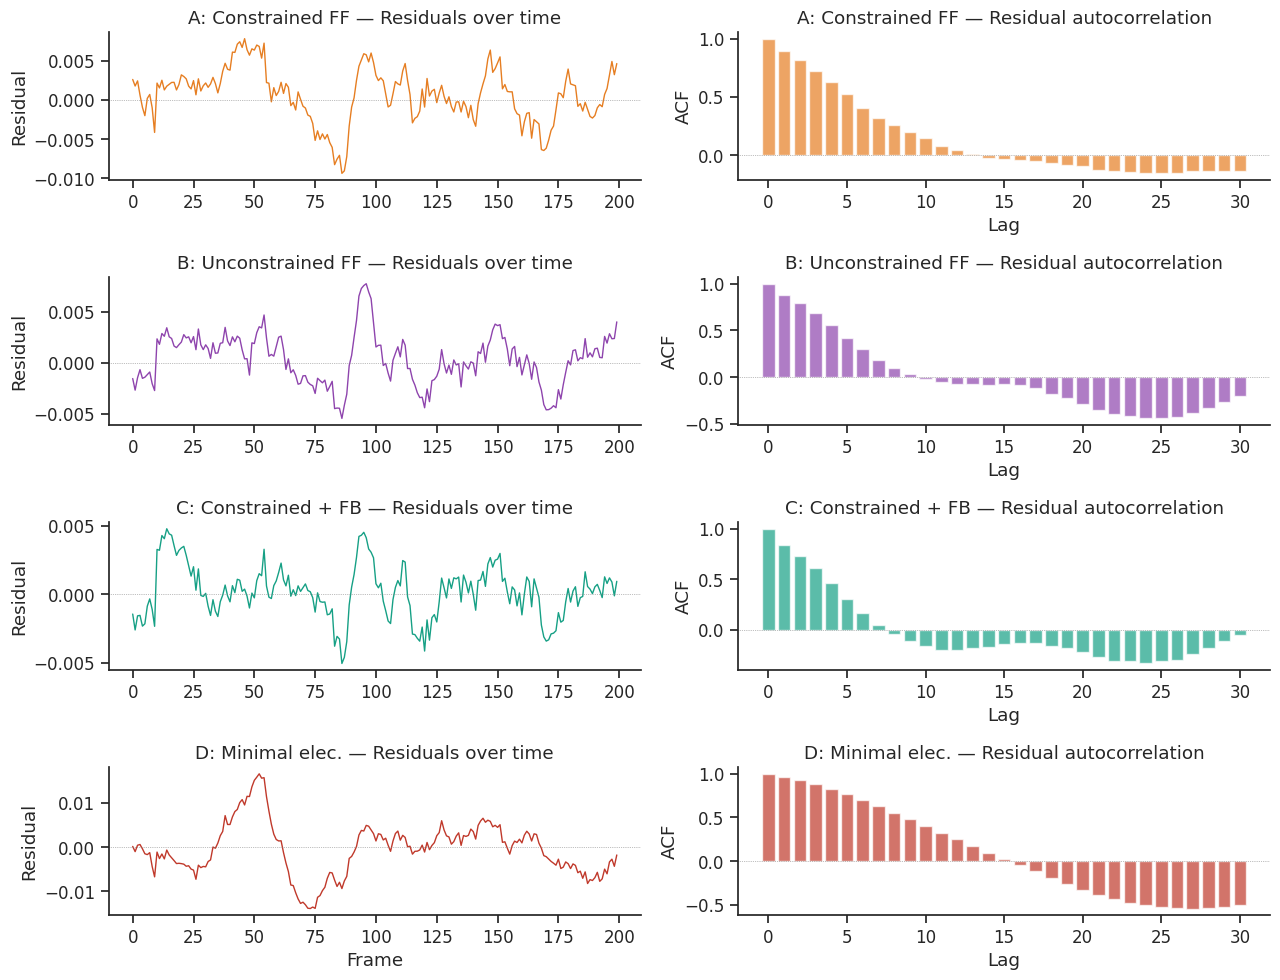

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(13, 10))
predictions = [
    ('A: Constrained FF', pred_constrained, '#E67E22'),
    ('B: Unconstrained FF', pred_unconstrained, '#8E44AD'),
    ('C: Constrained + FB', pred_feedback, '#16A085'),
    ('D: Minimal elec.', pred_minimal, '#C0392B'),
]

for row, (name, pred, col) in enumerate(predictions):
    resid = avb_mean - pred
    
    # Residual time series
    axes[row, 0].plot(t, resid, color=col, lw=1)
    axes[row, 0].axhline(0, color='grey', ls=':', lw=0.5)
    axes[row, 0].set_ylabel('Residual')
    axes[row, 0].set_title(f'{name} — Residuals over time')
    sns.despine(ax=axes[row, 0])
    
    # Autocorrelation of residuals
    max_lag = 30
    acf = np.correlate(resid - resid.mean(), resid - resid.mean(), mode='full')
    acf = acf[len(acf)//2:len(acf)//2 + max_lag + 1]
    acf /= acf[0]
    axes[row, 1].bar(range(max_lag + 1), acf, color=col, alpha=0.7, edgecolor='white')
    axes[row, 1].axhline(0, color='grey', ls=':', lw=0.5)
    axes[row, 1].set_xlabel('Lag')
    axes[row, 1].set_ylabel('ACF')
    axes[row, 1].set_title(f'{name} — Residual autocorrelation')
    sns.despine(ax=axes[row, 1])

axes[-1, 0].set_xlabel('Frame')
plt.tight_layout()
plt.show()

## 11. Circuit Diagram Summary

In [18]:
# Summarise fitted constrained model as a wiring diagram with strengths
p = result_constrained.x
fb_p = result_feedback.x
m_p = result_minimal.x

print('╔══════════════════════════════════════════════════════════════╗')
print('║       Fitted Two-Timescale Circuit — Model A (6 params)    ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║                                                            ║')
print(f'║   ASH ──chem──▶ AVB   b={p[2]:+.4f}, τ={p[3]:.1f} frames          ║')
print(f'║   AVA ══gap═══▶ AVB   a={p[0]:+.4f}   (fast)               ║')
print(f'║   AVA ──chem──▶ AVB   b={p[4]:+.4f}, τ={p[5]:.1f} frames          ║')
print(f'║   AVD ══gap═══▶ AVB   a={p[1]:+.4f}   (fast)               ║')
print('║                                                            ║')
print('║   Feedback variant (Model C) adds:                        ║')
print(f'║   AVB ──chem──▶ AVA   c={fb_p[6]:+.4f}, τ={fb_p[7]:.1f} frames          ║')
print('║                                                            ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║       Minimal Electrical — Model D (5 params)              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║                                                            ║')
print(f'║   ASH ──chem──▶ AVB   b={m_p[1]:+.4f}, τ={m_p[2]:.1f} frames          ║')
print(f'║   AVA ══gap═══▶ AVB   a={m_p[0]:+.4f}   (fast)               ║')
print(f'║   AVA ──chem──▶ AVB   b={m_p[3]:+.4f}, τ={m_p[4]:.1f} frames          ║')
print(f'║   AVD ══gap═══▶ AVB   a= 0.0000   (removed)              ║')
print('║                                                            ║')
print('╚══════════════════════════════════════════════════════════════╝')

print('\nInterpretation guide:')
print('  positive a → gap junction passes excitation (same-sign coupling)')
print('  negative a → gap junction has rectifying/inhibitory effect')
print('  positive b → chemical synapse is excitatory (tonic)')
print('  negative b → chemical synapse is inhibitory')
print('  large τ   → slow integration (long memory)')
print('  small τ   → fast decay (short-lived effect)')

╔══════════════════════════════════════════════════════════════╗
║       Fitted Two-Timescale Circuit — Model A (6 params)    ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║   ASH ──chem──▶ AVB   b=+0.0014, τ=61.2 frames          ║
║   AVA ══gap═══▶ AVB   a=-0.4828   (fast)               ║
║   AVA ──chem──▶ AVB   b=+0.1024, τ=14.2 frames          ║
║   AVD ══gap═══▶ AVB   a=-0.9384   (fast)               ║
║                                                            ║
║   Feedback variant (Model C) adds:                        ║
║   AVB ──chem──▶ AVA   c=-1.5826, τ=36.3 frames          ║
║                                                            ║
╠══════════════════════════════════════════════════════════════╣
║       Minimal Electrical — Model D (5 params)              ║
╠══════════════════════════════════════════════════════════════╣
║                                                            ║
║ 

## 12. Sensitivity Analysis — How Much Does Each Pathway Matter?

Drop one pathway at a time and measure the R² decrease.

Ablated pathway                           R²      ΔR²
-------------------------------------------------------
None (full model)                     0.8688        —
AVA gap junction (a_AVA)             -0.0519  +0.9207
AVD gap junction (a_AVD)             -6.8490  +7.7179
ASH chemical (b_ASH)                  0.7898  +0.0791
AVA chemical (b_AVA)                 -7.4160  +8.2849


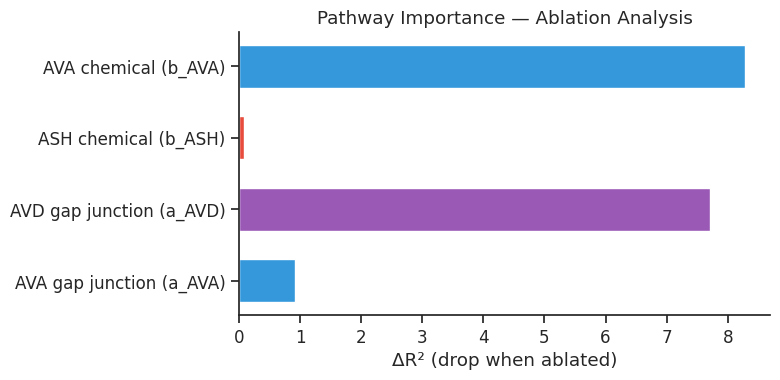

In [19]:
# Ablation analysis: set each parameter to zero and measure R² drop
p_best = result_constrained.x.copy()

ablation_results = {}
pathway_labels = {
    0: 'AVA gap junction (a_AVA)',
    1: 'AVD gap junction (a_AVD)',
    2: 'ASH chemical (b_ASH)',
    4: 'AVA chemical (b_AVA)',
}

print(f'{"Ablated pathway":35s} {"R²":>8s} {"ΔR²":>8s}')
print('-' * 55)
print(f'{"None (full model)":35s} {r2_constrained:8.4f} {"—":>8s}')

for idx, label in pathway_labels.items():
    p_ablated = p_best.copy()
    p_ablated[idx] = 0.0
    pred_abl = predict_avb_feedforward(p_ablated, ash_mean, ava_mean, avd_mean, dt, constrained=True)
    r2_abl = r2_score(avb_mean, pred_abl)
    ablation_results[label] = r2_constrained - r2_abl
    print(f'{label:35s} {r2_abl:8.4f} {r2_constrained - r2_abl:+8.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(ablation_results.keys())
deltas = list(ablation_results.values())
bar_colors = [colors['AVA'], colors['AVD'], colors['ASH'], colors['AVA']]
ax.barh(labels, deltas, color=bar_colors, edgecolor='white', height=0.6)
ax.set_xlabel('ΔR² (drop when ablated)')
ax.set_title('Pathway Importance — Ablation Analysis')
sns.despine()
plt.tight_layout()
plt.show()

## 13. Summary & Biological Interpretation

In [20]:
import pandas as pd

summary_df = pd.DataFrame([
    {'Model': 'A: Constrained FF', 'Params': 6, 'R²': r2_constrained,
     'MSE': result_constrained.fun,
     'AIC': compute_aic_bic(result_constrained.fun, T, 6)[0],
     'BIC': compute_aic_bic(result_constrained.fun, T, 6)[1]},
    {'Model': 'B: Unconstrained FF', 'Params': 9, 'R²': r2_unconstrained,
     'MSE': result_unconstrained.fun,
     'AIC': compute_aic_bic(result_unconstrained.fun, T, 9)[0],
     'BIC': compute_aic_bic(result_unconstrained.fun, T, 9)[1]},
    {'Model': 'C: Constrained + FB', 'Params': 8, 'R²': r2_feedback,
     'MSE': result_feedback.fun,
     'AIC': compute_aic_bic(result_feedback.fun, T, 8)[0],
     'BIC': compute_aic_bic(result_feedback.fun, T, 8)[1]},
    {'Model': 'D: Minimal elec.', 'Params': 5, 'R²': r2_minimal,
     'MSE': result_minimal.fun,
     'AIC': compute_aic_bic(result_minimal.fun, T, 5)[0],
     'BIC': compute_aic_bic(result_minimal.fun, T, 5)[1]},
])

print('\n=== FINAL MODEL COMPARISON ===')
print(summary_df.to_string(index=False, float_format='%.4f'))

print('\n\n=== INTERPRETATION NOTES ===')
print('''
Following Meng et al. (2024), the two-timescale model separates:
  • Fast coupling (a_i) — mediated by gap junctions (electrical synapses)
    Instantaneous, bidirectional, sign-preserving or rectifying
  • Slow coupling (b_i, τ_i) — mediated by chemical synapses
    Integrated over time, can be excitatory or inhibitory

Key questions to evaluate from the fits:
  1. Does the constrained model match or exceed the unconstrained?
     → If yes, the connectivity priors are consistent with the data.
  2. Does adding AVB→AVA feedback improve the model?
     → If the improvement is modest, the unidirectional (master-slave)
       configuration from Meng et al. may hold in dauers too.
  3. What are the signs and magnitudes of a_AVA and b_AVA?
     → Meng et al. found a < 0 (fast inhibition) and b > 0 (slow excitation).
       Do your dauer data show the same pattern?
  4. Does Model D (no AVD gap junction) perform comparably to Model A?
     → If yes, AVD's electrical coupling to AVB may be functionally
       negligible during spontaneous activity, simplifying the circuit.
     → If Model A is clearly better, AVD's gap junction plays a role.
''')


=== FINAL MODEL COMPARISON ===
              Model  Params     R²    MSE        AIC        BIC
  A: Constrained FF       6 0.8688 0.0000 -1685.7730 -1665.9831
B: Unconstrained FF       9 0.9326 0.0000 -1812.8267 -1783.1418
C: Constrained + FB       8 0.9595 0.0000 -1916.8360 -1890.4494
   D: Minimal elec.       5 0.6160 0.0000 -1472.9302 -1456.4386


=== INTERPRETATION NOTES ===

Following Meng et al. (2024), the two-timescale model separates:
  • Fast coupling (a_i) — mediated by gap junctions (electrical synapses)
    Instantaneous, bidirectional, sign-preserving or rectifying
  • Slow coupling (b_i, τ_i) — mediated by chemical synapses
    Integrated over time, can be excitatory or inhibitory

Key questions to evaluate from the fits:
  1. Does the constrained model match or exceed the unconstrained?
     → If yes, the connectivity priors are consistent with the data.
  2. Does adding AVB→AVA feedback improve the model?
     → If the improvement is modest, the unidirectional (master

## 14. Next Steps

Potential extensions to explore:

- **Sign constraints**: Enforce biologically expected signs (e.g., $a_{\text{AVA}} < 0$, $b_{\text{AVA}} > 0$ per Meng et al.) and compare.
- **Shared vs independent τ**: Test whether ASH and AVA chemical inputs share a time constant.
- **Nonlinear activation**: Replace the linear model with $\sigma(x)$ (sigmoidal) as in the full Meng et al. derivation.
- **State-dependent switching**: Allow parameters to differ during forward vs backward epochs.
- **Bootstrap confidence intervals**: Resample animals to get CIs on all parameters.
- **Granger causality**: Test whether adding each neuron's past improves prediction beyond AVB's own history.